# Градиентный бустинг

**Импорты и загрузка данных**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import load_npz
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score, precision_recall_curve, auc, average_precision_score

import xgboost as xgb
from xgboost import XGBClassifier
import pickle

In [ ]:
traindf = load_npz('x_train_tfidf.npz')
testdf = load_npz('x_test_tfidf.npz')

In [ ]:
X_train = traindf[:, :-1]
y_train = traindf[:, -1].toarray().ravel()

X_test = testdf[:, :-1]
y_test = testdf[:, -1].toarray().ravel()

print('размер X_train', X_train.shape)
print('размер Y_train', X_test.shape)

размер X_train (57707, 50000)
размер Y_train (14427, 50000)


**Подбор гипараметров**

Зададим большой learning_rate=0.3 для поиска оптимального количества n_estimators. После этого будем подбирать и остальные параметры.

1. Создадим функцию для поиска количества деревьев для нашей заданной базовой функции на learning_rate 0.3.

In [ ]:
def modelfit(model, X_train, y_train, X_test, y_test):

    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 67, stratify = y_train)

    model.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)])

    rez = model.evals_result()
    trainh = rez['validation_0']['auc']
    valh = rez['validation_1']['auc']
    n = model.best_iteration + 1

    plt.plot(trainh, label = 'train auc')
    plt.plot(valh, label = 'val auc')
    plt.axvline(n-1, label = f'лучший {n}')
    plt.xlabel('кол-во деревьев')
    plt.ylabel('roc-auc')
    plt.legend()
    plt.show()

    model.set_params(n_estimators = n, early_stopping_rounds = None)
    model.fit(X_train, y_train)

    train_pred = model.predict_proba(X_train)[:, 1]
    test_pred = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)

    print('лучший n_estimators:', n, 'train roc-auc результат:', train_auc, 'test roc-auc результат:', test_auc)

    return model

Бзаовая модель и применение на нней функции

[0]	validation_0-auc:0.95028	validation_1-auc:0.80126
[1]	validation_0-auc:0.96329	validation_1-auc:0.80207
[2]	validation_0-auc:0.97034	validation_1-auc:0.87415
[3]	validation_0-auc:0.97423	validation_1-auc:0.87676
[4]	validation_0-auc:0.97979	validation_1-auc:0.92329
[5]	validation_0-auc:0.98234	validation_1-auc:0.92601
[6]	validation_0-auc:0.98405	validation_1-auc:0.92639
[7]	validation_0-auc:0.98585	validation_1-auc:0.93235
[8]	validation_0-auc:0.98672	validation_1-auc:0.93161
[9]	validation_0-auc:0.98783	validation_1-auc:0.93546
[10]	validation_0-auc:0.98881	validation_1-auc:0.93794
[11]	validation_0-auc:0.98941	validation_1-auc:0.93801
[12]	validation_0-auc:0.99008	validation_1-auc:0.93807
[13]	validation_0-auc:0.99087	validation_1-auc:0.93841
[14]	validation_0-auc:0.99153	validation_1-auc:0.93797
[15]	validation_0-auc:0.99206	validation_1-auc:0.93796
[16]	validation_0-auc:0.99258	validation_1-auc:0.93808
[17]	validation_0-auc:0.99304	validation_1-auc:0.93876
[18]	validation_0-au

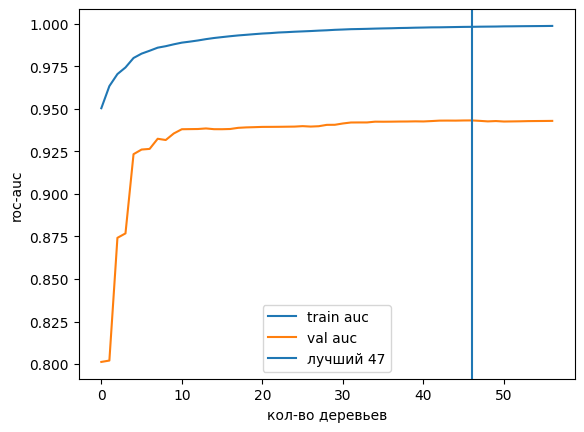

лучший n_estimators: 47 train roc-auc результат: 0.9977447939164045 test roc-auc результат: 0.9939009580138117


In [ ]:
model_xgb = XGBClassifier(learning_rate = 0.3, n_estimators = 100, objective = 'binary:logistic', eval_metric = 'auc', early_stopping_rounds = 10, tree_method = 'hist', n_jobs = -1, random_state = 67)
model_xgb = modelfit(model_xgb, X_train, y_train, X_test, y_test)

Получили, что оптимальное количество деревевьев при подборе вышло 47. При этом значения AUC-ROC при изменении n_estimators выходят на прямую примерно начиная с 15 деревьев. Заметно, ято и качество модели у нас хорошее, также переобучения особо нет, если смотреть на различие кривых для тестовой и валидационной.
Поэтому для наших данных будем рассматривать n_estimators равный 15, так как это в этом случае уместно

Подбор max_depth и min_child_weight

зададим значения из которых будем выбирать

In [ ]:
param_test1 = {'max_depth': [3, 5], 'min_child_weight': [1, 3]}
gsearch1 = GridSearchCV(estimator=XGBClassifier(learning_rate = 0.3, n_estimators = 15, objective = 'binary:logistic', eval_metric = 'auc', tree_method = 'hist', n_jobs = -1, random_state = 67),
                         param_grid = param_test1, scoring = 'roc_auc', cv = 3, n_jobs = -1)
gsearch1.fit(X_train, y_train)
print('Лучшие параметры:', gsearch1.best_params_)
print('Лучший ROC-AUC:', gsearch1.best_score_)

Лучшие параметры: {'max_depth': 5, 'min_child_weight': 1}
Лучший ROC-AUC: 0.98538436303331


получили max_depth = 5 и min_child_weight = 1. AUC-ROC высокий

Подбор gamma


In [ ]:
param_test2 = {'gamma': [0.0, 0.1, 0.3]}

gsearch2 = GridSearchCV(estimator=XGBClassifier(learning_rate = 0.3, n_estimators = model_xgb.n_estimators, max_depth = 5, min_child_weight = 1, objective = 'binary:logistic', eval_metric = 'auc', tree_method = 'hist', n_jobs = -1, random_state = 67),
                        param_grid = param_test2, scoring = 'roc_auc', cv = 3, n_jobs = -1)
gsearch2.fit(X_train, y_train)
print('Лучшие параметры:', gsearch2.best_params_)
print('Лучший ROC-AUC:', gsearch2.best_score_)

Лучшие параметры: {'gamma': 0.0}
Лучший ROC-AUC: 0.9923086932892081


значение для gamma = 0

Подбор subsample и colsample_bytree


In [ ]:
param_test3 = {'subsample': [0.7, 0.9], 'colsample_bytree': [0.7, 0.9]}

gsearch3 = GridSearchCV(estimator=XGBClassifier(learning_rate = 0.3, n_estimators = 15, max_depth = 5, min_child_weight = 1, gamma = 0.0, objective = 'binary:logistic', eval_metric = 'auc', tree_method = 'hist', n_jobs = -1, random_state = 67),
                        param_grid = param_test3, scoring = 'roc_auc', cv = 3, n_jobs = -1)
gsearch3.fit(X_train, y_train)
print('Лучшие параметры:', gsearch3.best_params_)
print('Лучший ROC-AUC:', gsearch3.best_score_)

Лучшие параметры: {'colsample_bytree': 0.7, 'subsample': 0.9}
Лучший ROC-AUC: 0.9854230963568872


Подбор регуляризации reg_alpha


In [ ]:
param_test4 = {'reg_alpha': [0, 0.1, 1]}

gsearch4 = GridSearchCV(estimator=XGBClassifier(learning_rate = 0.3, n_estimators = 15, max_depth = 5, min_child_weight = 1, gamma = 0.0,
                        subsample = 0.9, colsample_bytree = 0.7, objective = 'binary:logistic', eval_metric = 'auc', tree_method = 'hist', n_jobs = -1, random_state = 67), param_grid = param_test4,
                        scoring = 'roc_auc', cv = 3, n_jobs = -1)
gsearch4.fit(X_train, y_train)
print('Лучшие параметры:', gsearch4.best_params_)
print('Лучший ROC-AUC:', gsearch4.best_score_)

Лучшие параметры: {'reg_alpha': 0}
Лучший ROC-AUC: 0.9854230963568872


**Уменьшение learning_rate, финальная модель**



Итоговые гиперпараметры: learning_rate = 0.03, n_estimators = 150, max_depth = 5, min_child_weight = 1, gamma = 0, subsample = 0.9, colsample_bytree = 0.7, reg_alpha = 0
[0]	validation_0-auc:0.93736	validation_1-auc:0.89455
[1]	validation_0-auc:0.94893	validation_1-auc:0.89455
[2]	validation_0-auc:0.95824	validation_1-auc:0.89643
[3]	validation_0-auc:0.96900	validation_1-auc:0.89719
[4]	validation_0-auc:0.97206	validation_1-auc:0.91510
[5]	validation_0-auc:0.97165	validation_1-auc:0.91563
[6]	validation_0-auc:0.97262	validation_1-auc:0.91864
[7]	validation_0-auc:0.97341	validation_1-auc:0.91871
[8]	validation_0-auc:0.97331	validation_1-auc:0.91875
[9]	validation_0-auc:0.97359	validation_1-auc:0.91874
[10]	validation_0-auc:0.97640	validation_1-auc:0.92897
[11]	validation_0-auc:0.97775	validation_1-auc:0.93371
[12]	validation_0-auc:0.97774	validation_1-auc:0.93370
[13]	validation_0-auc:0.97812	validation_1-auc:0.93355
[14]	validation_0-auc:0.97812	validation_1-auc:0.93348
[15]	validation

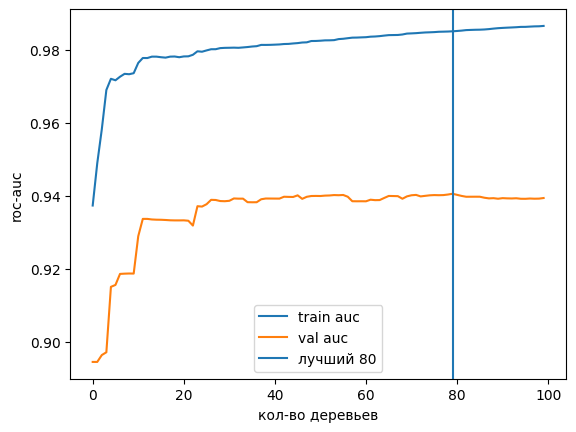

лучший n_estimators: 80 train roc-auc результат: 0.9846672319723955 test roc-auc результат: 0.9845647250284595


In [ ]:
model_final = XGBClassifier(learning_rate = 0.03, n_estimators = 150, max_depth = 5, min_child_weight = 1, gamma = 0.0,
    subsample = 0.9, colsample_bytree = 0.7, reg_alpha = 0, objective = 'binary:logistic', eval_metric = 'auc',
    early_stopping_rounds = 20, tree_method = 'hist', n_jobs = -1, random_state=67)

print('Итоговые гиперпараметры: learning_rate = 0.03, n_estimators = 150, max_depth = 5, min_child_weight = 1, gamma = 0, subsample = 0.9, colsample_bytree = 0.7, reg_alpha = 0')
model_final = modelfit(model_final, X_train, y_train, X_test, y_test)

Получили результат roc-auc равный 0.98, что очень хорошо. При этом видим,что значение roc_auc и при 80 деревьях сработала также. Отклонение между кривыми есть, но сильного переобучения не наблюдается.

## Оценка качества

In [ ]:
y_pred = model_final.predict(X_test)
y_pred_proba = model_final.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names = ['Реальныые', 'Фейковые']))
print('ROC-AUC:', roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

   Реальныые       0.97      0.91      0.94      7006
    Фейковые       0.92      0.97      0.94      7421

    accuracy                           0.94     14427
   macro avg       0.94      0.94      0.94     14427
weighted avg       0.94      0.94      0.94     14427

ROC-AUC: 0.9845647250284595


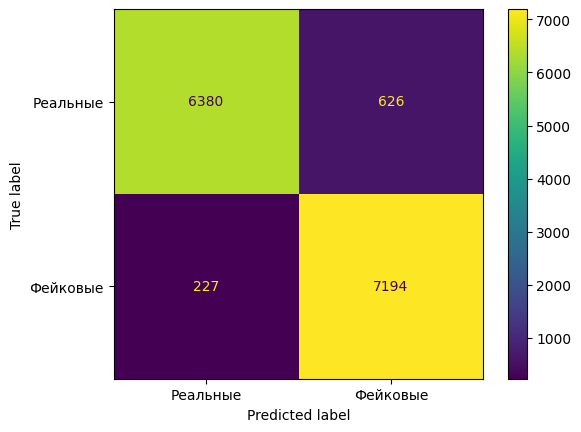

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['Реальные', 'Фейковые'])
disp.plot()

Наша модель очень хорошо находит фейковые новости, реальные несколько хуже. При этом модель довольно часто относит реальные новости к фейкам. Наша основная задача выполняется так как все же фейковые новости распознаются на очень хорошем уровне.

Text(0.5, 1.0, 'ROC-кривая')

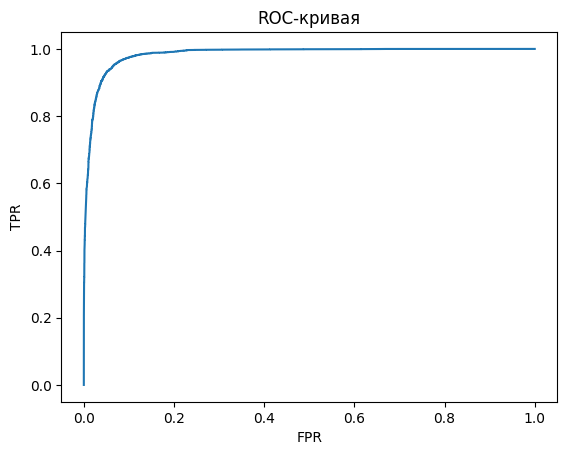

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC-кривая')


ROC-кривая проходит рядом с единицей (верхним левом углом), поэтому все хорошо

PR-AUC: 0.9839831989394449
Средний Precision: 0.9838580847468368


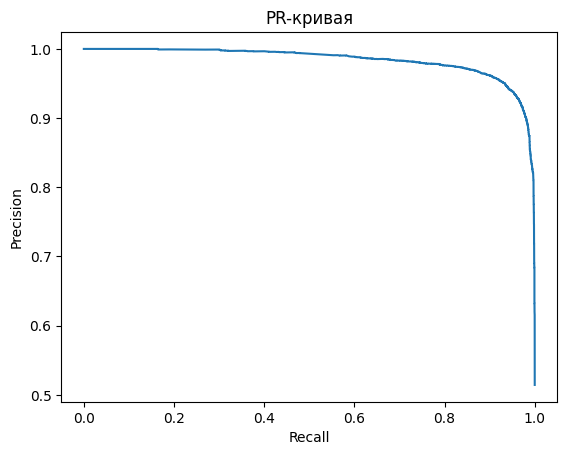

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
avg_precision = average_precision_score(y_test, y_pred_proba)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривая')

print('PR-AUC:', pr_auc)
print('Средний Precision:', avg_precision)

PR-кривая проходит рядом с единицей (верхний, правый угол), поэтому все хорошо. Также само значение тоже очень высокое.